<a href="https://colab.research.google.com/github/Mohamed-Boutarbouch/Auth-System-for-Laravel-Sanctum-in-React/blob/main/hahahahahahah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLOv8 Object Detection + Depth-Anything-V2 Distance Estimation on KITTI

This notebook demonstrates a pipeline for:
1. Setting up the environment and downloading the KITTI dataset.
2. Performing Exploratory Data Analysis (EDA) on the object detection data.
3. Converting KITTI object detection labels to the YOLO format.
4. Training a YOLOv8 object detection model on the KITTI dataset.
5. Evaluating the trained YOLOv8 model.
6. Setting up the Depth-Anything-V2 model and fine-tuning it on KITTI depth data.
7. Performing inference with both models to detect objects and estimate their distance, annotating the output image.

## 1. Setup and Install Dependencies

In [ ]:
!pip install -q ultralytics matplotlib pandas seaborn opencv-python-headless torch torchvision torchaudio torchviz torchinfo scikit-image pillow tqdm scipy pyyaml requests psutil py-cpuinfo timm transformers huggingface_hub

In [ ]:
import os
import cv2
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import shutil
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from ultralytics import YOLO
from glob import glob
import random

# PyTorch imports for Depth Model
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

# Import Depth Anything V2 model components (using transformers as preferred)
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Download and Prepare KITTI Dataset

We'll download the necessary parts of the KITTI dataset: Left color images, Calibration files, Velodyne point clouds (optional, for reference), Object detection labels, and Depth prediction ground truth.

**Note:** Downloading the full dataset can take significant time and storage space. Ensure you have sufficient resources.

In [ ]:
DATA_DIR = Path('./kitti_data')
IMG_DIR = DATA_DIR / 'object' / 'training' / 'image_2'
LABEL_DIR = DATA_DIR / 'object' / 'training' / 'label_2'
CALIB_DIR = DATA_DIR / 'object' / 'training' / 'calib'
DEPTH_GT_DIR = DATA_DIR / 'depth' / 'train'

IMG_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)
CALIB_DIR.mkdir(parents=True, exist_ok=True)
DEPTH_GT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# --- Downloading Commands (Example using wget - requires registration & link updates) ---
# You might need to manually download from http://www.cvlibs.net/datasets/kitti/ and upload/unzip
# or use a dataset mirror/API if available.

print("Downloading KITTI object detection data...")
# Images (Approx. 12GB)
!wget -c -N https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip -P {DATA_DIR}
!unzip -qn {DATA_DIR}/data_object_image_2.zip -d {DATA_DIR}/object
!rm {DATA_DIR}/data_object_image_2.zip

# Labels (Approx. 5MB)
!wget -c -N https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip -P {DATA_DIR}
!unzip -qn {DATA_DIR}/data_object_label_2.zip -d {DATA_DIR}/object

# Calibration (Approx. 26MB)
!wget -c -N https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_calib.zip -P {DATA_DIR}
!unzip -qn {DATA_DIR}/data_object_calib.zip -d {DATA_DIR}/object

print("Downloading KITTI depth prediction ground truth data...")
# Depth Ground Truth (Approx. 22GB) - This is from the 'depth prediction' challenge
!wget -c -N https://s3.eu-central-1.amazonaws.com/avg-kitti/data_depth_annotated.zip -P {DATA_DIR}
!unzip -qn {DATA_DIR}/data_depth_annotated.zip -d {DATA_DIR}/depth
!rm {DATA_DIR}/data_object_image_2.zip

# Clean up zip files
!rm {DATA_DIR}/*.zip

# Verify directories contain files
print(f"Images found: {len(list(IMG_DIR.glob('*.png')))}")
print(f"Labels found: {len(list(LABEL_DIR.glob('*.txt')))}")
print(f"Calibration files found: {len(list(CALIB_DIR.glob('*.txt')))}")
print(f"Depth GT files found: {len(list(DEPTH_GT_DIR.glob('*/*.png')))} (Looked in subdirs)")

# Note: KITTI depth data is split into train/val folders inside 'data_depth_annotated'
# We might need to combine or structure them depending on the fine-tuning requirements.

## 3. Exploratory Data Analysis (EDA)

Number of images: 7481
Number of label files: 7481


Reading Labels:   0%|          | 0/7481 [00:00<?, ?it/s]

Total annotations (relevant classes): 40570

Class Distribution:
class
Car               28742
Pedestrian         4487
Van                2914
Cyclist            1627
Truck              1094
Misc                973
Tram                511
Person_sitting      222
Name: count, dtype: int64


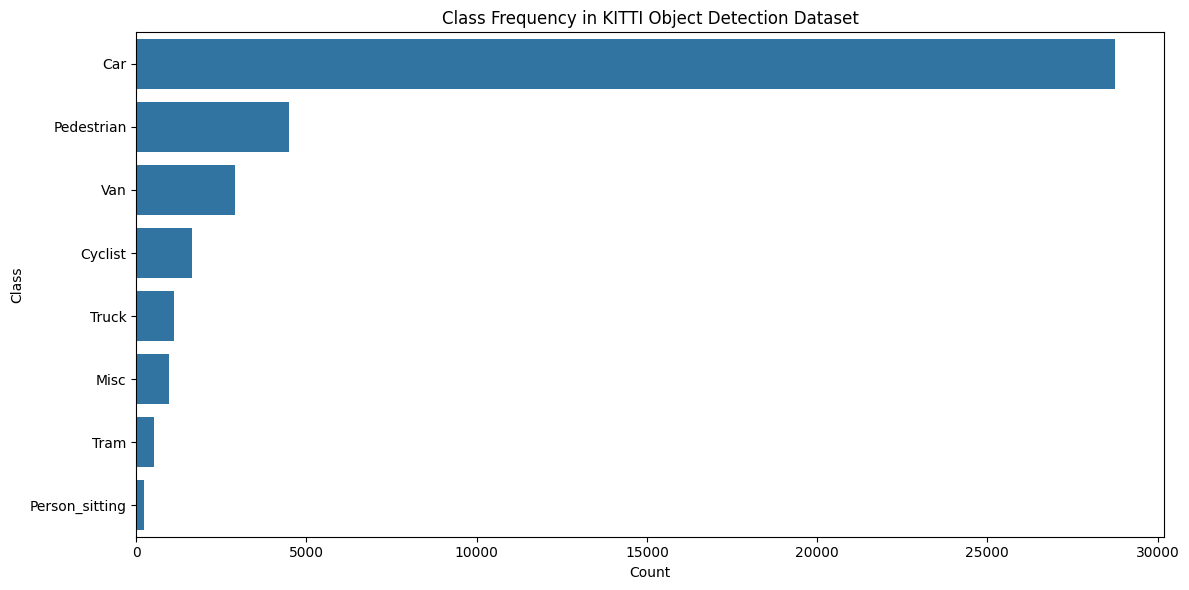

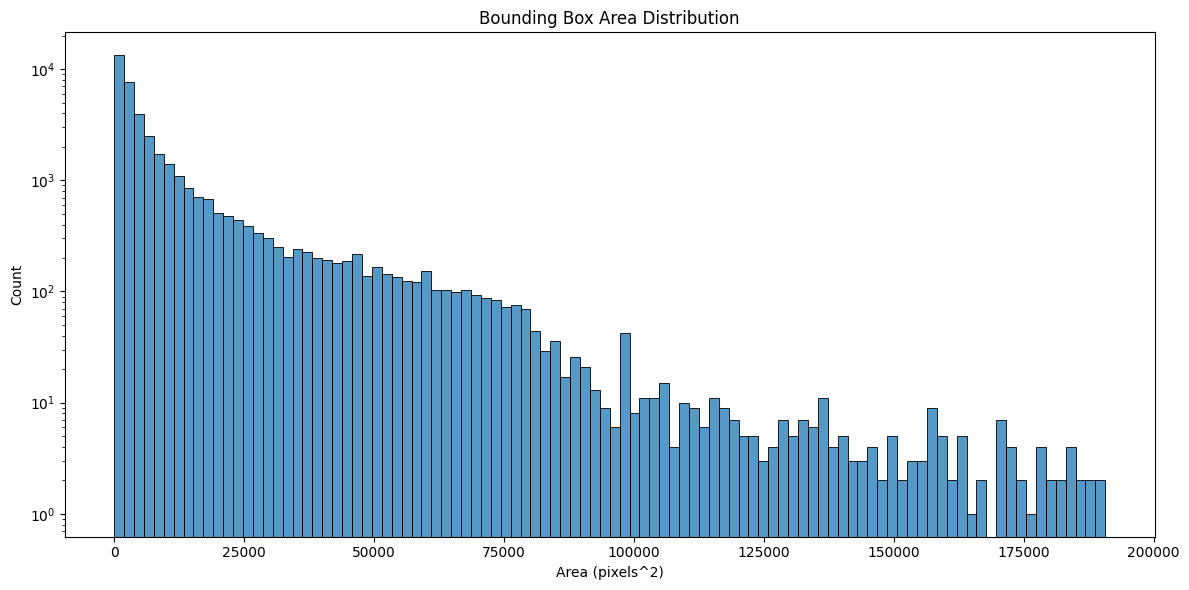


Showing sample images with Ground Truth boxes...


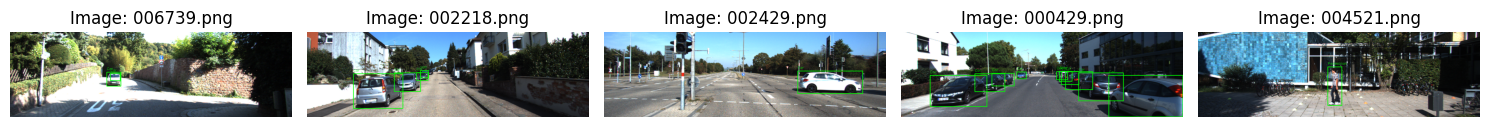

In [ ]:
label_files = sorted(list(LABEL_DIR.glob('*.txt')))
image_files = sorted(list(IMG_DIR.glob('*.png')))
num_images = len(image_files)

print(f"Number of images: {num_images}")
print(f"Number of label files: {len(label_files)}")

# Read all labels into a pandas DataFrame
kitti_classes_of_interest = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc'] # KITTI's 8 classes for detection
all_labels_data = []
total_annotations = 0

for label_file in tqdm(label_files, desc="Reading Labels"):
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_name = parts[0]
            if class_name in kitti_classes_of_interest:
                xmin = float(parts[4])
                ymin = float(parts[5])
                xmax = float(parts[6])
                ymax = float(parts[7])
                width = xmax - xmin
                height = ymax - ymin
                area = width * height
                all_labels_data.append({'class': class_name, 'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax, 'width': width, 'height': height, 'area': area})
                total_annotations += 1

df_labels = pd.DataFrame(all_labels_data)

print(f"Total annotations (relevant classes): {total_annotations}")
print("\nClass Distribution:")
print(df_labels['class'].value_counts())

# Plot Class Frequency
plt.figure(figsize=(12, 6))
sns.countplot(y='class', data=df_labels, order=df_labels['class'].value_counts().index)
plt.title('Class Frequency in KITTI Object Detection Dataset')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

In [ ]:
# Plot Bounding Box Area Histogram
plt.figure(figsize=(12, 6))
sns.histplot(df_labels['area'], bins=100, kde=False)
plt.title('Bounding Box Area Distribution')
plt.xlabel('Area (pixels^2)')
plt.ylabel('Count')
# Consider log scale if distribution is highly skewed
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
print("\nShowing sample images with Ground Truth boxes...")
# Show sample images with GT boxes
num_samples_to_show = 5
sample_indices = random.sample(range(num_images), num_samples_to_show)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(sample_indices):
    img_path = image_files[idx]
    label_path = LABEL_DIR / (img_path.stem + '.txt')

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_name = parts[0]
                if class_name in kitti_classes_of_interest:
                    xmin = int(float(parts[4]))
                    ymin = int(float(parts[5]))
                    xmax = int(float(parts[6]))
                    ymax = int(float(parts[7]))
                    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
                    cv2.putText(img, class_name, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    plt.subplot(1, num_samples_to_show, i + 1)
    plt.imshow(img)
    plt.title(f'Image: {img_path.name}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Convert Labels to YOLO Format

In [ ]:
YOLO_DATA_DIR = Path('./yolo_kitti')
YOLO_IMG_DIR = YOLO_DATA_DIR / 'images' / 'train'
YOLO_LABEL_DIR = YOLO_DATA_DIR / 'labels' / 'train'

# Clean previous attempts if any
if YOLO_DATA_DIR.exists():
    shutil.rmtree(YOLO_DATA_DIR)

YOLO_IMG_DIR.mkdir(parents=True, exist_ok=True)
YOLO_LABEL_DIR.mkdir(parents=True, exist_ok=True)

# KITTI classes to YOLO integer IDs (0-7)
kitti_class_map = {
    'Car': 0,
    'Van': 1,
    'Truck': 2,
    'Pedestrian': 3,
    'Person_sitting': 4,
    'Cyclist': 5,
    'Tram': 6,
    'Misc': 7
    # 'DontCare' class is ignored as per typical YOLO practice for KITTI
}

def kitti_to_yolo(kitti_box, img_width, img_height):
    """Converts KITTI bbox (xmin, ymin, xmax, ymax) to YOLO normalized (cx, cy, w, h)"""
    xmin, ymin, xmax, ymax = kitti_box
    dw = 1.0 / img_width
    dh = 1.0 / img_height
    cx = (xmin + xmax) / 2.0
    cy = (ymin + ymax) / 2.0
    w = xmax - xmin
    h = ymax - ymin
    cx *= dw
    w *= dw
    cy *= dh
    h *= dh
    return cx, cy, w, h

skipped_files = 0
processed_files = 0
for img_path in tqdm(image_files, desc="Converting Labels"):
    label_path = LABEL_DIR / (img_path.stem + '.txt')
    yolo_label_path = YOLO_LABEL_DIR / (img_path.stem + '.txt')

    if not label_path.exists():
        print(f"Warning: Label file not found for {img_path.name}")
        skipped_files += 1
        continue

    try:
        img = Image.open(img_path)
        img_width, img_height = img.size

        yolo_labels = []
        with open(label_path, 'r') as f_kitti:
            for line in f_kitti:
                parts = line.strip().split()
                class_name = parts[0]
                if class_name in kitti_class_map:
                    class_id = kitti_class_map[class_name]
                    kitti_box = [float(parts[4]), float(parts[5]), float(parts[6]), float(parts[7])]

                    # Clamp boxes to image dimensions before conversion
                    kitti_box[0] = max(0, kitti_box[0])
                    kitti_box[1] = max(0, kitti_box[1])
                    kitti_box[2] = min(img_width - 1, kitti_box[2])
                    kitti_box[3] = min(img_height - 1, kitti_box[3])

                    if kitti_box[2] <= kitti_box[0] or kitti_box[3] <= kitti_box[1]:
                         continue # Skip invalid boxes

                    cx, cy, w, h = kitti_to_yolo(kitti_box, img_width, img_height)
                    yolo_labels.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        if yolo_labels: # Only write file and copy image if there are valid labels
            with open(yolo_label_path, 'w') as f_yolo:
                f_yolo.write('\n'.join(yolo_labels))
            # Copy the corresponding image
            shutil.copy(str(img_path), str(YOLO_IMG_DIR / img_path.name))
            processed_files += 1
        else:
             # print(f"Info: No relevant labels found for {img_path.name}, skipping.")
             skipped_files +=1
    except Exception as e:
        print(f"Error processing {img_path.name}: {e}")
        skipped_files += 1

print(f"\nConversion complete.")
print(f"Processed {processed_files} image/label pairs.")
print(f"Skipped {skipped_files} files (no labels or errors).")

# Create data.yaml file
data_yaml_content = {
    'path': str(YOLO_DATA_DIR.resolve()), # dataset root dir
    'train': 'images/train', # train images (relative to 'path')
    'val': 'images/train',  # Use train also as val for this example, adjust if you have a split
    'test': '', # test images (optional)
    'nc': len(kitti_class_map), # number of classes
    'names': list(kitti_class_map.keys()) # class names
}

with open(YOLO_DATA_DIR / 'data.yaml', 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"Created {YOLO_DATA_DIR / 'data.yaml'}")

Converting Labels:   0%|          | 0/7481 [00:00<?, ?it/s]


Conversion complete.
Processed 7481 image/label pairs.
Skipped 0 files (no labels or errors).
Created yolo_kitti/data.yaml


## 5. Train YOLOv8

We'll train a YOLOv8n model on our converted KITTI dataset.

In [ ]:
# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train the model on the KITTI dataset
results = model.train(
    data=str(YOLO_DATA_DIR / 'data.yaml'),
    epochs=2,
    imgsz=640,
    batch=16,
    device=device, # Use GPU if available
    name='yolov8n_kitti_train' # Name for the results directory
)

print("Training finished.")

engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=yolo_kitti/data.yaml, epochs=2, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=yolov8n_kitti_train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=False, int8=False, dynamic=

train: Scanning /content/yolo_kitti/labels/train... 7481 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7481/7481 [00:33<00:00, 223.16it/s]


train: New cache created: /content/yolo_kitti/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2035.5±1748.6 MB/s, size: 790.1 KB)


val: Scanning /content/yolo_kitti/labels/train.cache... 7481 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7481/7481 [00:00<?, ?it/s]


Plotting labels to runs/detect/yolov8n_kitti_train3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000833, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/yolov8n_kitti_train3
Starting training for 2 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       7481      40570      0.509      0.388      0.354      0.211

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        2/2       2.4G      1.206      1.098      1.034        103        640: 100%|██████████| 468/468 [03:05<00:00,  2.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 234/234 [01:41<00:00,  2.30it/s]


                   all       7481      40570      0.639      0.454      0.503      0.309

2 epochs completed in 0.165 hours.
Optimizer stripped from runs/detect/yolov8n_kitti_train3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolov8n_kitti_train3/weights/best.pt, 6.2MB

Validating runs/detect/yolov8n_kitti_train3/weights/best.pt...
Ultralytics 8.3.119 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 234/234 [01:52<00:00,  2.07it/s]


                   all       7481      40570      0.639      0.455      0.503      0.309
                   Car       6684      28742      0.869      0.772      0.874      0.609
                   Van       2145       2914      0.632      0.468      0.545      0.384
                 Truck       1036       1094      0.486      0.684      0.644      0.456
            Pedestrian       1779       4487      0.612      0.533      0.578      0.297
        Person_sitting         99        222          1    0.00512      0.174     0.0758
               Cyclist       1141       1627      0.652       0.38      0.455      0.229
                  Tram        349        511      0.379      0.708      0.572      0.309
                  Misc        778        973      0.484     0.0886       0.18      0.112
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/detect/yolov8n_kitti_train3
Training finished.


## 6. Evaluate YOLOv8 Performance

Loading best weights from: runs/detect/yolov8n_kitti_train3/weights/best.pt
Running validation...
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in in the future.
Ultralytics 8.3.119 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2463.5±1392.7 MB/s, size: 791.5 KB)


val: Scanning /content/yolo_kitti/labels/train.cache... 7481 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7481/7481 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 468/468 [02:01<00:00,  3.86it/s]


                   all       7481      40570       0.64      0.455      0.503      0.309
                   Car       6684      28742      0.869      0.772      0.874      0.609
                   Van       2145       2914      0.632      0.467      0.546      0.385
                 Truck       1036       1094      0.487      0.685      0.644      0.458
            Pedestrian       1779       4487      0.614      0.532      0.578      0.297
        Person_sitting         99        222          1    0.00508      0.175     0.0764
               Cyclist       1141       1627      0.653       0.38      0.456      0.229
                  Tram        349        511      0.378      0.706      0.573      0.309
                  Misc        778        973      0.484     0.0884       0.18      0.111
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Saving runs/detect/val2/predictions.json...
Results saved to runs/detect/val2

Validation Metrics:
  mAP50-95: 0.3092

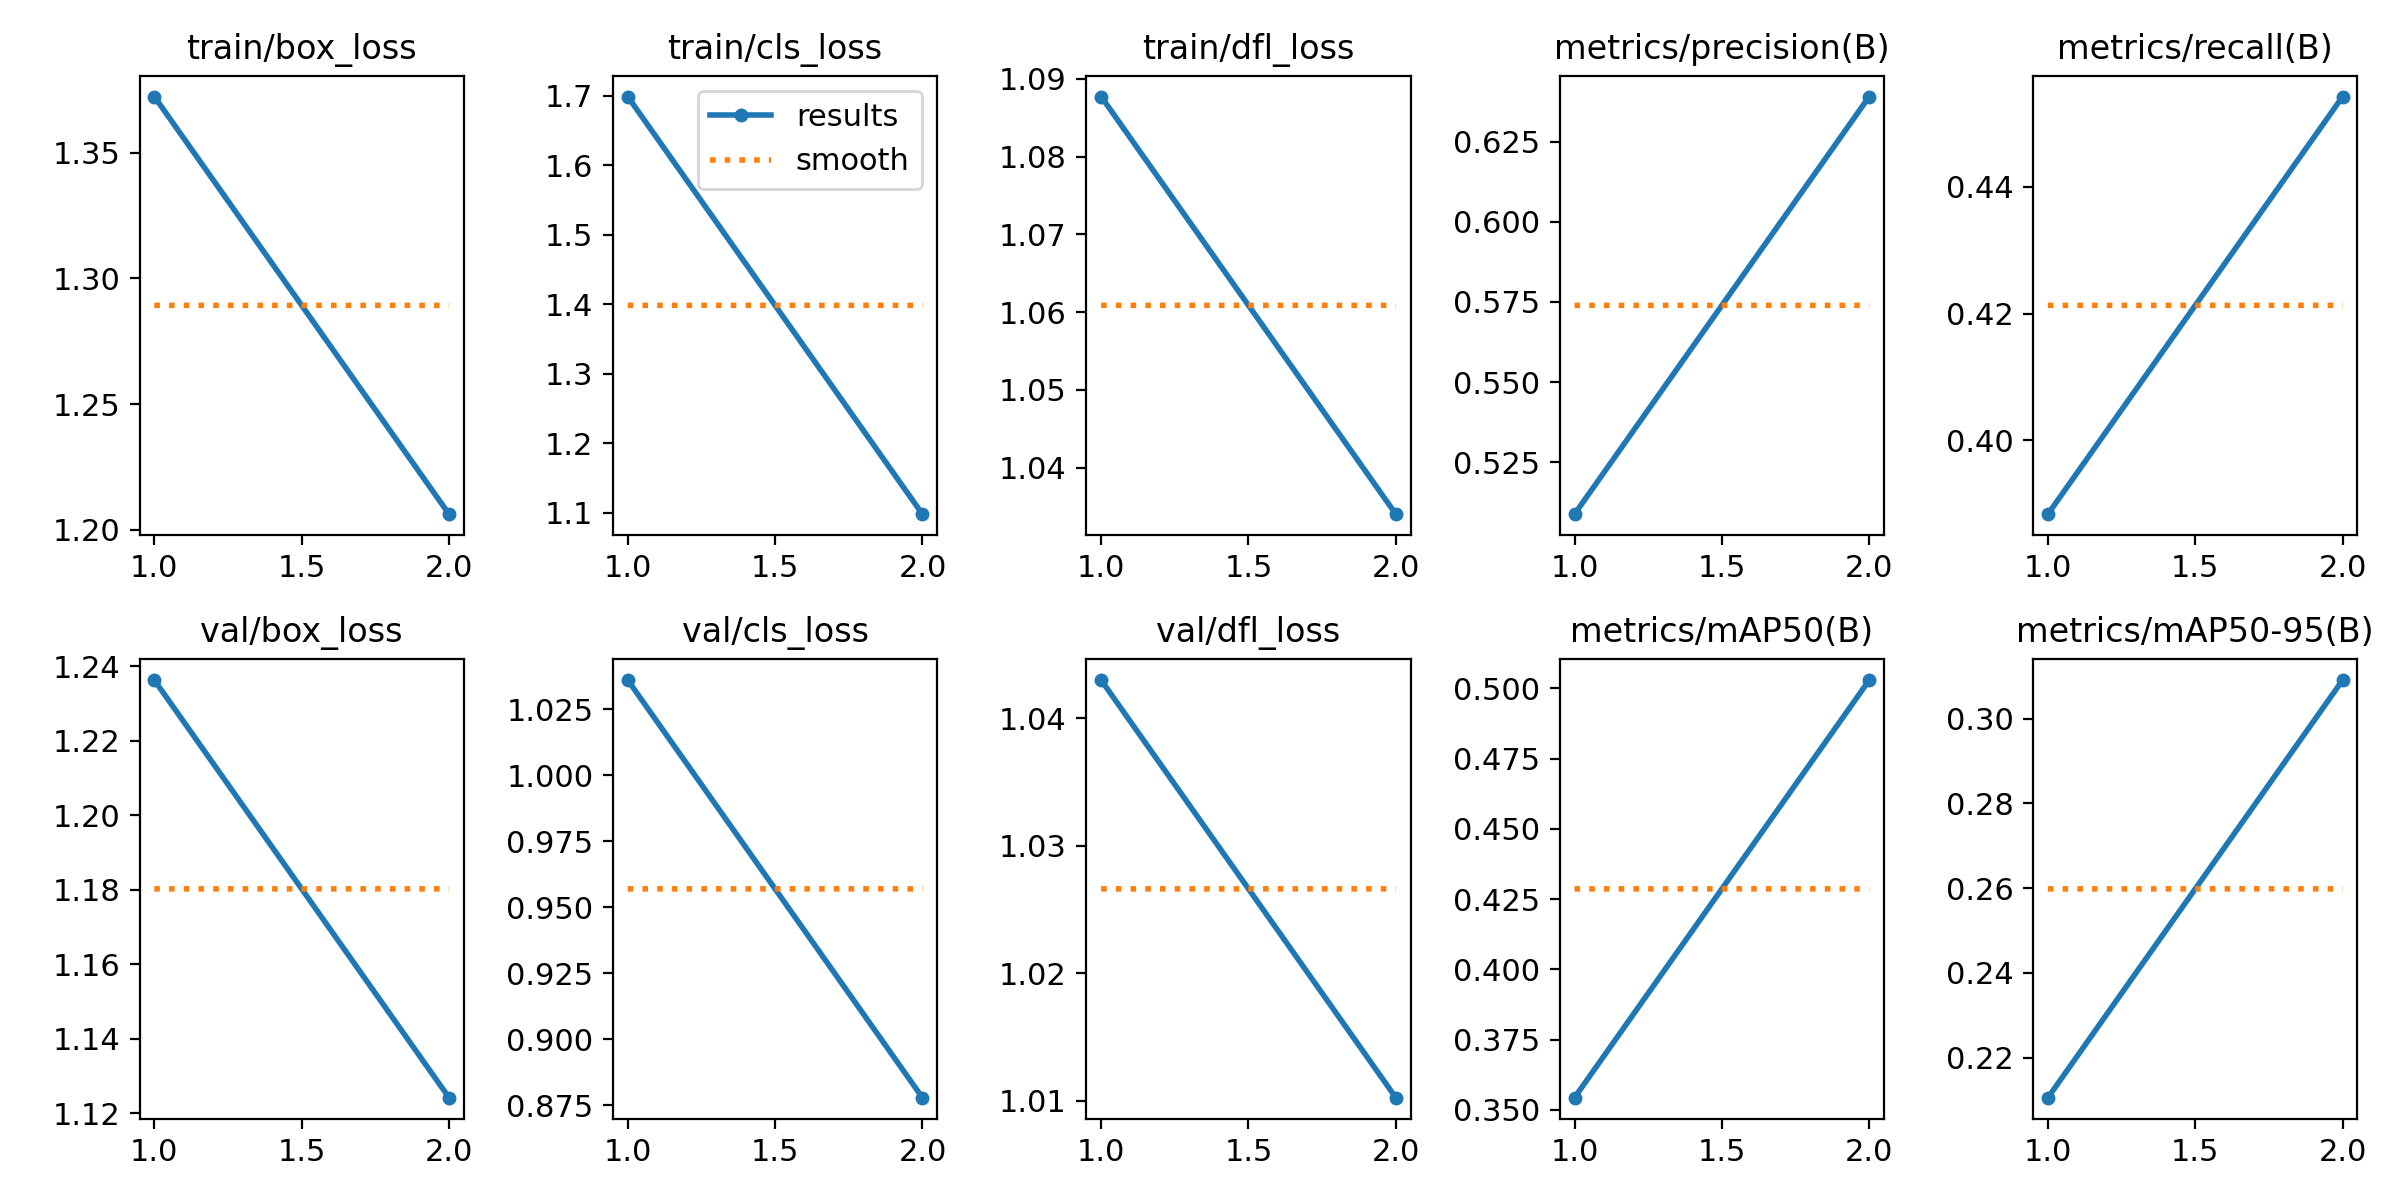

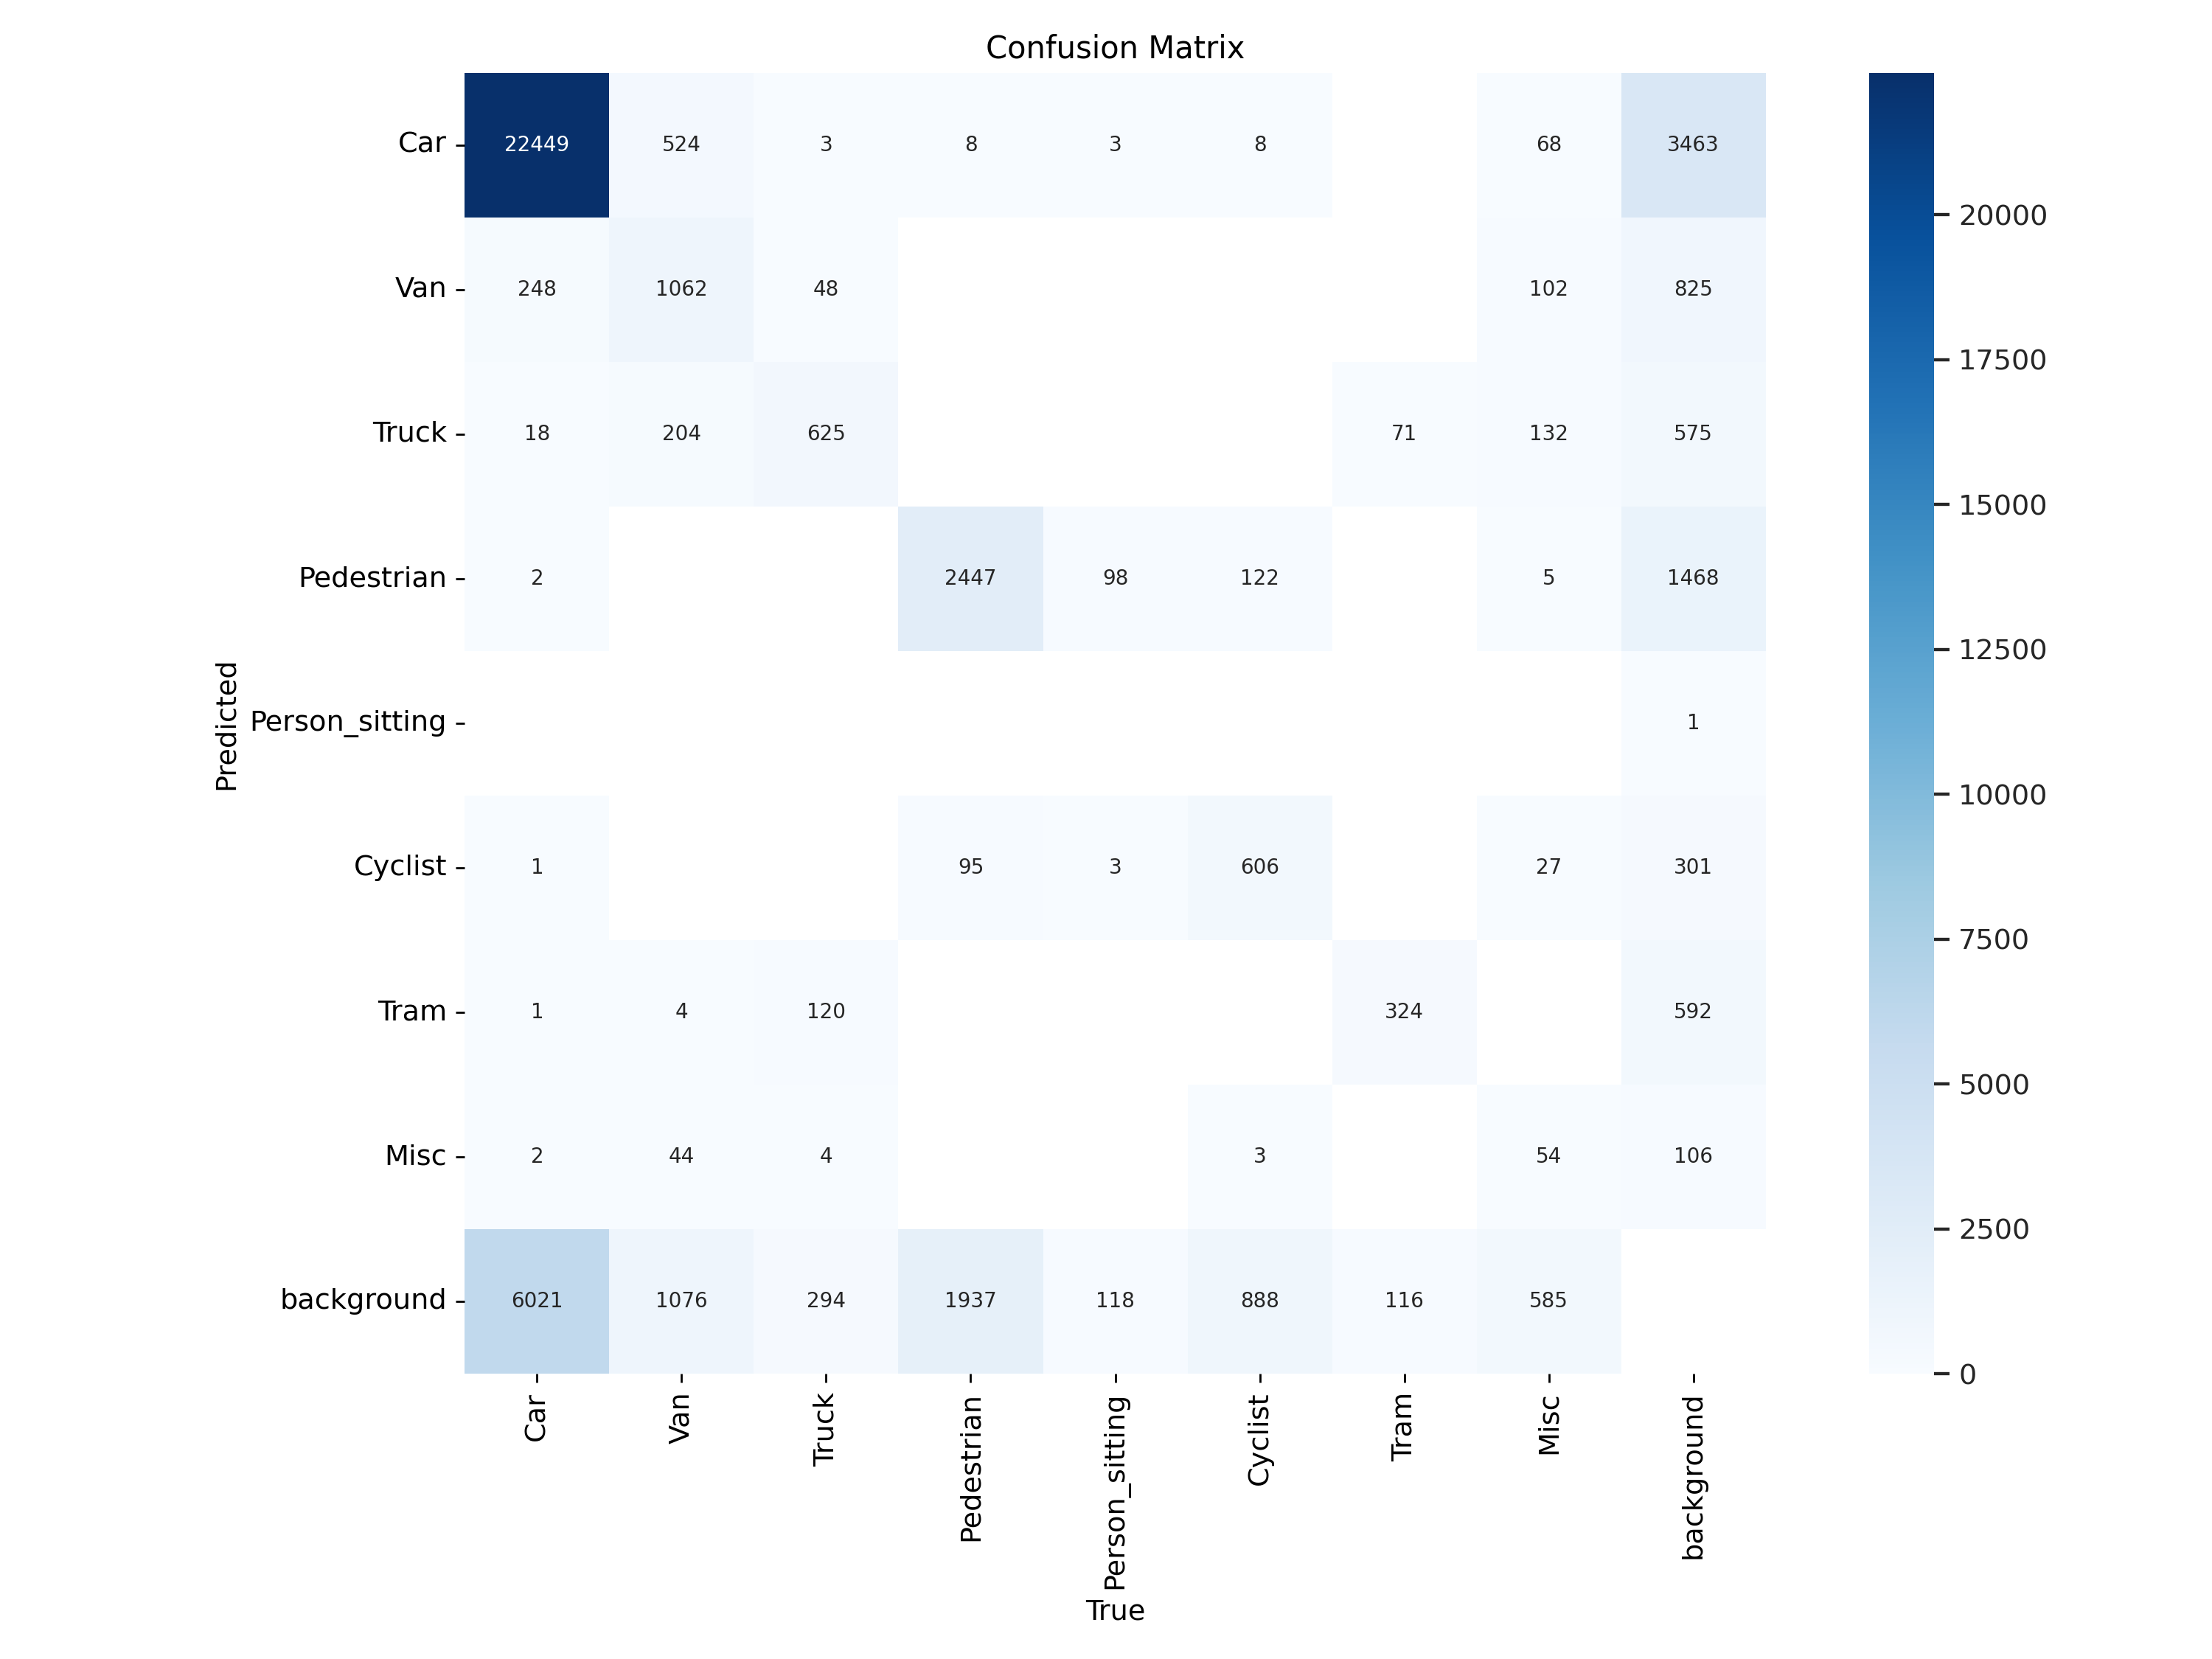

In [ ]:
# Find the path to the best trained weights
results_dir = Path(results.save_dir) # Access the save directory from the results object
weights_path = results_dir / 'weights' / 'best.pt'

if weights_path.exists():
    print(f"Loading best weights from: {weights_path}")
    # Load the best model
    model = YOLO(weights_path)

    # Evaluate the model on the validation set (using train set as val in this example)
    print("Running validation...")
    metrics = model.val(data=str(YOLO_DATA_DIR / 'data.yaml'),
                      split='val', # Explicitly specify the split
                      save_json=True, # Save results to JSON for pycocotools evaluation
                      save_hybrid=True # Save hybrid format labels (labels + preds)
                      )

    # Print key metrics
    print("\nValidation Metrics:")
    print(f"  mAP50-95: {metrics.box.map:.4f}")
    print(f"  mAP50:    {metrics.box.map50:.4f}")
    print(f"  mAP75:    {metrics.box.map75:.4f}")
    # Precision and Recall might need specific calculation or are part of the detailed output
    # Check metrics object attributes or the saved files for P & R if needed.
    # print(f"  Precision: {metrics.box.p[0]:.4f}") # Example, check correct attribute
    # print(f"  Recall:    {metrics.box.r[0]:.4f}") # Example, check correct attribute

    # Display results plots saved during validation
    print(f"\nPlots saved in: {metrics.save_dir}")
    try:
        from IPython.display import Image as IPImage, display
        print("Displaying result plots:")
        results_png = list(results_dir.glob('results.png'))
        confusion_png = list(results_dir.glob('confusion_matrix.png'))
        if results_png:
             display(IPImage(filename=results_png[0]))
        if confusion_png:
             display(IPImage(filename=confusion_png[0]))
    except Exception as e:
        print(f"Could not display plots: {e}")

else:
    print(f"Error: Best weights file not found at {weights_path}")

## 7. Depth-Anything-V2 Setup & Fine-tuning

Load the Depth-Anything-V2 model using transformers (as preferred by HuggingFace docs for this model architecture) and fine-tune it on the KITTI depth prediction ground truth.

In [ ]:
# Define model name (adjust if needed, e.g., vits, vitb, vitl)
# Using small version for faster fine-tuning in Colab
depth_model_name = "depth-anything/Depth-Anything-V2-Small-hf"

print(f"Loading depth model: {depth_model_name}")
try:
    # Load processor and model using Transformers
    depth_processor = AutoImageProcessor.from_pretrained(depth_model_name)
    depth_model = AutoModelForDepthEstimation.from_pretrained(depth_model_name)
    depth_model.to(device)
    print("Depth model loaded successfully.")
except Exception as e:
    print(f"Error loading depth model: {e}")
    # Handle error, maybe try torch.hub or different model variant if needed
    depth_model = None # Ensure model is None if loading fails

Loading depth model: depth-anything/Depth-Anything-V2-Small-hf


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Depth model loaded successfully.


### Prepare KITTI Depth Dataset for Fine-tuning

In [ ]:
import re

# --- Dataset ---
class KITTIDepthDataset(Dataset):
    def __init__(self, depth_root_dir, rgb_root_dir, phase='train', processor=None, transforms=None):
        self.depth_root_dir = Path(depth_root_dir)
        self.rgb_root_dir = Path(rgb_root_dir)
        self.phase = phase
        self.processor = processor
        self.transforms = transforms

        self.image_depth_pairs = []

        depth_glob_pattern = f'{phase}/*/proj_depth/groundtruth/image_02/*.png'
        print(f"Searching for depth maps in: {self.depth_root_dir / phase} using pattern: {depth_glob_pattern}")
        found_depth_files = sorted(list(self.depth_root_dir.glob(depth_glob_pattern)))
        print(f"Found {len(found_depth_files)} potential depth maps.")

        for depth_path in tqdm(found_depth_files, desc="Pairing Images and Depth Maps"):
            try:
                frame_match = re.search(r'(\d+)\.png$', str(depth_path.name))
                if not frame_match:
                    continue

                rgb_filename = f"{depth_path.stem[:6]}.png"
                rgb_path = self.rgb_root_dir / rgb_filename

                if rgb_path.exists():
                    self.image_depth_pairs.append((rgb_path, depth_path))

            except Exception as e:
                print(f"Error processing depth path {depth_path}: {e}")

        print(f"Found {len(self.image_depth_pairs)} matched image/depth pairs for phase {self.phase}")

    def __len__(self):
        return len(self.image_depth_pairs)

    def __getitem__(self, idx):
        img_path, depth_path = self.image_depth_pairs[idx]

        try:
            image = Image.open(img_path).convert("RGB")
            depth_map = Image.open(depth_path)
            depth_map = np.array(depth_map).astype(np.float32)

            valid_mask = depth_map > 0
            depth_map[valid_mask] = depth_map[valid_mask] / 256.0

            if self.processor:
                inputs = self.processor(images=image, return_tensors="pt")
                pixel_values = inputs['pixel_values'].squeeze(0)

                depth_tensor = torch.from_numpy(depth_map).unsqueeze(0).unsqueeze(0)
                target_height, target_width = 384, 384
                depth_tensor = F.interpolate(depth_tensor, size=(target_height, target_width), mode='nearest')
                depth_tensor = depth_tensor.squeeze(0).squeeze(0)
            else:
                if self.transforms:
                    pixel_values = self.transforms(image)
                else:
                    pixel_values = transforms.ToTensor()(image)
                depth_tensor = torch.from_numpy(depth_map)

            return {'pixel_values': pixel_values, 'labels': depth_tensor}

        except Exception as e:
            print(f"Error loading item {idx}: {e}")
            raise e # Let DataLoader handle if an error occurs

# --- Create Dataset and Subset ---
try:
    kitti_depth_annotated_dir = DATA_DIR / 'depth'
    kitti_object_rgb_dir = DATA_DIR / 'object' / 'training' / 'image_2'

    if not kitti_depth_annotated_dir.exists():
        raise FileNotFoundError(f"Depth directory not found: {kitti_depth_annotated_dir}")
    if not kitti_object_rgb_dir.exists():
        raise FileNotFoundError(f"RGB directory not found: {kitti_object_rgb_dir}")

    full_train_dataset = KITTIDepthDataset(
        depth_root_dir=kitti_depth_annotated_dir,
        rgb_root_dir=kitti_object_rgb_dir,
        phase='train',
        processor=depth_processor
    )

    if len(full_train_dataset) == 0:
        raise ValueError("No matched image/depth pairs found!")

    # --- Select a random subset indices only ---
    subset_size = 100  # smaller subset for Colab RAM
    actual_subset_size = min(subset_size, len(full_train_dataset))
    subset_indices = random.sample(range(len(full_train_dataset)), actual_subset_size)

    train_subset_dataset = Subset(full_train_dataset, subset_indices)

    # --- DataLoader ---
    train_loader = DataLoader(train_subset_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
    print(f"Created DataLoader with {len(train_subset_dataset)} training samples.")

except Exception as e:
    print(f"Error creating Dataset/DataLoader: {e}")
    train_loader = None

Searching for depth maps in: kitti_data/depth/train using pattern: train/*/proj_depth/groundtruth/image_02/*.png
Found 42949 potential depth maps.


Pairing Images and Depth Maps:   0%|          | 0/42949 [00:00<?, ?it/s]

Found 42949 matched image/depth pairs for phase train
Created DataLoader with 100 training samples.


### Fine-tuning Loop

In [ ]:
if depth_model and train_loader:
    print("Starting fine-tuning...")
    depth_model.train() # Set model to training mode

    # Define Loss Function (Example: Scale-invariant log loss - SILog)
    # This often requires custom implementation or finding a library
    # Using simpler L1 loss for demonstration
    criterion = nn.L1Loss()

    # Define Optimizer
    optimizer = optim.Adam(depth_model.parameters(), lr=1e-5)

    num_epochs = 5

    for epoch in range(num_epochs):
        running_loss = 0.0
        # Ensure tqdm is imported, e.g., from tqdm.notebook import tqdm
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch in progress_bar:
            inputs = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()

            # Forward pass
            with torch.set_grad_enabled(True):
                outputs = depth_model(pixel_values=inputs)
                predicted_depth = outputs.predicted_depth

                # Ensure labels and predictions have compatible shapes and handle potential NaN/Inf
                # Resize prediction to match label size if needed (or vice-versa)
                predicted_depth_resized = F.interpolate(predicted_depth.unsqueeze(1),
                                                        size=labels.shape[-2:],
                                                        mode='bicubic',
                                                        align_corners=False).squeeze(1)

                # Mask invalid pixels (e.g., where GT depth is 0 or <=0)
                mask = labels > 0
                if mask.sum() == 0: # Skip batch if no valid GT pixels
                    continue

                loss = criterion(predicted_depth_resized[mask], labels[mask])

                # Backward pass and optimize
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            # Format the loss value before putting it in the dictionary
            current_loss = loss.item()
            progress_bar.set_postfix({'loss': f'{current_loss:.4f}'})


        # Calculate epoch loss using the length of the filtered dataset subset
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss:.4f}')

        # Optional: Add validation loop here if val_loader exists

    print("Fine-tuning finished.")

    # Save the fine-tuned model
    save_path = Path('./depth_anything_v2_finetuned_kitti.pth')
    torch.save(depth_model.state_dict(), save_path)
    print(f"Fine-tuned model saved to {save_path}")

    # Set model back to evaluation mode
    depth_model.eval()
else:
    print("Skipping fine-tuning due to model or data loading issues.")

Starting fine-tuning...


Epoch 1/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/5 Loss: 5.3749


Epoch 2/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2/5 Loss: 4.3178


...

Epoch 3/5 Loss: 4.0585


Epoch 4/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 4/5 Loss: 4.0329


Epoch 5/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 5/5 Loss: 3.8487
Fine-tuning finished.
Fine-tuned model saved to depth_anything_v2_finetuned_kitti.pth


## 8. Distance Estimation & Annotation

Processing image: 002409.png

0: 224x640 9 Cars, 2 Vans, 2 Trucks, 1 Misc, 49.1ms
Speed: 5.4ms preprocess, 49.1ms inference, 7.4ms postprocess per image at shape (1, 3, 224, 640)

Displaying Annotated Image:


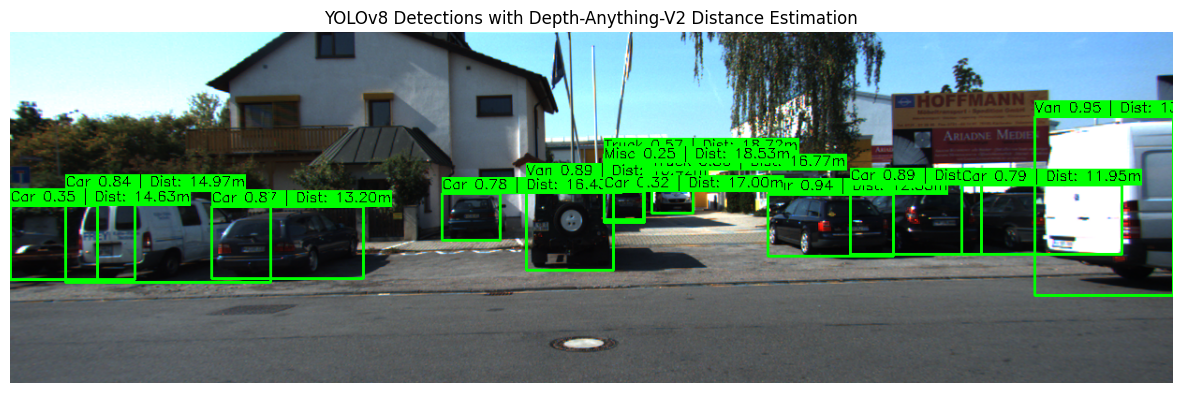


Displaying Predicted Depth Map:


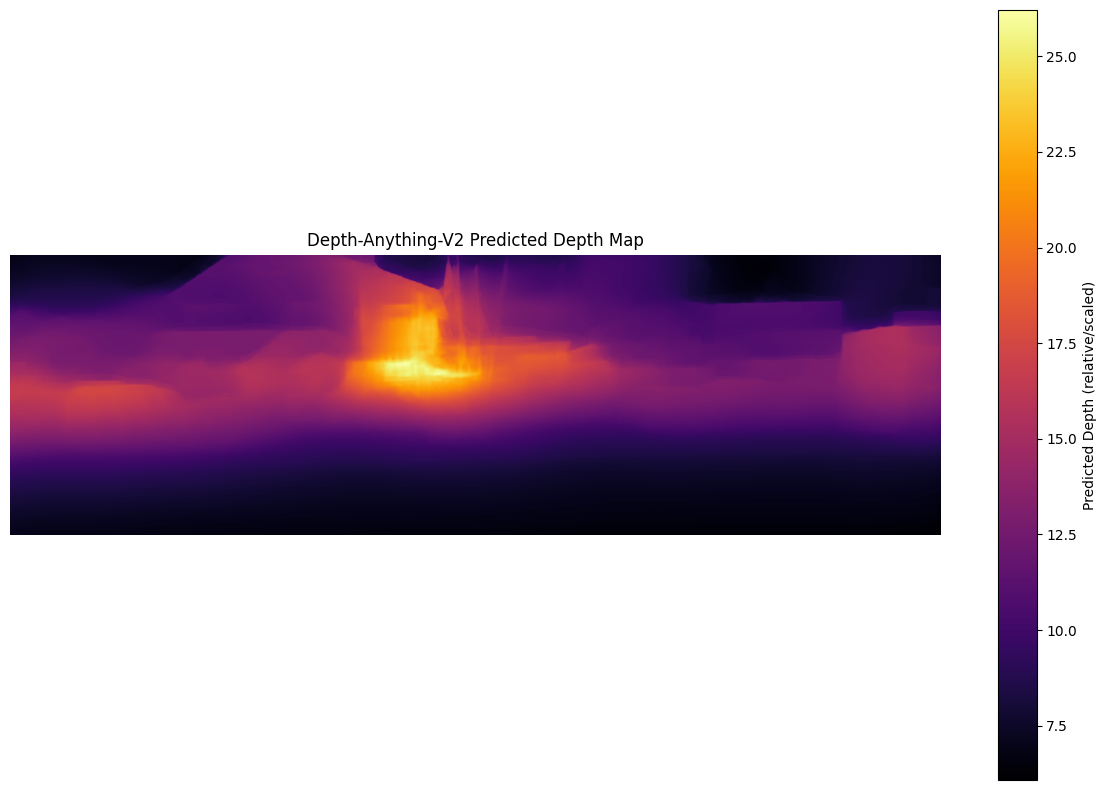

In [ ]:
# Load a sample image (use one from your dataset)
# Assuming YOLO_IMG_DIR has images after conversion step
sample_img_path = None
if YOLO_IMG_DIR.exists() and len(list(YOLO_IMG_DIR.glob('*.png'))) > 0:
     sample_img_path = random.choice(list(YOLO_IMG_DIR.glob('*.png')))
elif len(image_files) > 0:
     # Fallback to original KITTI image dir if YOLO dir is empty
     sample_img_path = random.choice(image_files)
     print(f"Warning: YOLO image dir empty, using original KITTI image: {sample_img_path.name}")
else:
    print("Error: No sample images found.")

if sample_img_path and depth_model:
    print(f"Processing image: {sample_img_path.name}")
    img_bgr = cv2.imread(str(sample_img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)

    # 1. Run YOLOv8 Inference
    yolo_results = model(img_pil) # Use the evaluated YOLO model

    # 2. Run Fine-tuned Depth-Anything-V2 Inference
    depth_model.eval() # Ensure model is in eval mode
    inputs = depth_processor(images=img_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = depth_model(**inputs)
        predicted_depth = outputs.predicted_depth

    # Interpolate prediction to original image size
    prediction = F.interpolate(
        predicted_depth.unsqueeze(1),
        size=img_rgb.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()
    depth_map_pred = prediction.cpu().numpy()

    # --- Optional: Scale depth map if needed (e.g., using calibration or known distances) ---
    # For simplicity, we'll use the direct output, but scaling might be necessary for metric accuracy
    # scaled_depth_map = depth_map_pred * scale_factor # Determine scale_factor appropriately
    scaled_depth_map = depth_map_pred # Using unscaled for demo

    # 3. Annotate Image
    img_annotated = img_bgr.copy()
    boxes = yolo_results[0].boxes
    class_names = yolo_results[0].names

    for box in boxes:
        try:
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            conf = box.conf.item()
            cls_id = int(box.cls.item())
            class_name = class_names[cls_id]

            # Calculate center of the bounding box
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)

            # Ensure center coordinates are within image bounds
            h, w = img_annotated.shape[:2]
            center_x = max(0, min(w - 1, center_x))
            center_y = max(0, min(h - 1, center_y))

            # Sample depth at the center
            depth_value = scaled_depth_map[center_y, center_x]

            # Filter detections by confidence maybe?
            # if conf < 0.5: continue

            # Draw bounding box
            cv2.rectangle(img_annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Create label text
            # label = f"{class_name} {conf:.2f} | Dist: {depth_value:.2f}m"
            label = f"{class_name}: {depth_value:.2f}m"

            # Put label text above the box
            (label_width, label_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img_annotated, (x1, y1 - label_height - baseline), (x1 + label_width, y1), (0, 255, 0), cv2.FILLED)
            cv2.putText(img_annotated, label, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
        except IndexError:
            print("Warning: Skipping a box due to potential index error.")
        except Exception as e:
             print(f"Error annotating box: {e}")

    # Display the annotated image
    print("\nDisplaying Annotated Image:")
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("YOLOv8 Detections with Depth-Anything-V2 Distance Estimation")
    plt.show()

    # Display the predicted depth map
    print("\nDisplaying Predicted Depth Map:")
    plt.figure(figsize=(15, 10))
    plt.imshow(depth_map_pred, cmap='inferno')
    plt.colorbar(label='Predicted Depth (relative/scaled)')
    plt.axis('off')
    plt.title("Depth-Anything-V2 Predicted Depth Map")
    plt.show()
else:
    print("Skipping final annotation step due to missing image or depth model.")

## 9. Conclusion

This notebook covered the process of using the KITTI dataset for object detection with YOLOv8 and depth estimation with Depth-Anything-V2. Key steps included data download, EDA, label conversion, YOLO training/evaluation, depth model fine-tuning, and combined inference for distance estimation.

Further improvements could involve:
* Implementing a proper train/validation split for both object detection and depth estimation.
* Using more sophisticated depth map scaling techniques.
* Experimenting with different YOLOv8 model sizes (s, m, l, x).
* Fine-tuning hyperparameters for both models.
* More rigorous evaluation of the depth estimation accuracy.
* Handling the 'DontCare' class more explicitly during label conversion if needed.